In [1]:
import numpy as np
from sklearn.decomposition import PCA
from scipy.stats import percentileofscore
import matplotlib.pyplot as plt
plt.style.use("ggplot")

In [2]:
train_data = np.load("training_data.npy")
yobs = np.load("true_samps/y_obs.npy")
T = 18
u_dim = 4
yu_dimension = (T, u_dim)
ys, us = train_data[:, :T], train_data[:, T:]
log_ys = np.log(ys)

In [3]:
# Step 1: Reduce to a PCA subspace that captures most variance
pca = PCA(n_components=0.95)  # keep enough PCs for 95% explained variance. Does this subtract mean?
ys_pca = pca.fit_transform(log_ys)
print(f"Number of PCs retained: {pca.n_components_}")

Number of PCs retained: 7


In [4]:
yobs_pca = pca.transform(yobs.reshape(1,-1))
yobs_pc1 = yobs_pca[0,0]

In [9]:
def snr_calc(yt):
    snr_t = (np.var(yt) - 1.0) / 1.0
    snr_t_db = 10 * np.log10(snr_t)
    return snr_t_db
snr_vals = np.array([snr_calc(np.log(y)) for y in ys])
np.max(snr_vals)

/tmp/ipykernel_703741/1329797989.py:3: RuntimeWarning: invalid value encountered in log10
  snr_t_db = 10 * np.log10(snr_t)


np.float32(nan)

In [10]:
snr_vals = snr_vals[~np.isnan(snr_vals)]
np.max(snr_vals)

np.float32(33.871048)

In [11]:
np.mean(snr_vals)

np.float32(5.9567027)

In [19]:
pc1 = ys_pca[:, 0]
percentile = percentileofscore(pc1, yobs_pc1)
# PC1 ranges from ~-300 (rare/tail) to ~+25 (typical/dense)
idx_typical  = np.argmin(np.abs(pc1 - np.percentile(pc1, percentile)))
idx_moderate = np.argmin(np.abs(pc1 - np.percentile(pc1, 25)))
idx_rare     = np.argmin(np.abs(pc1 - np.percentile(pc1,  11)))

# y_typical  = ys[idx_typical]
y_typical = yobs
y_moderate = ys[idx_moderate]
y_rare     = ys[idx_rare]

print(f"PC1 values selected:")
print(f"  Typical  ({percentile:.0f}th pct): {pc1[idx_typical]:.2f}")
print(f"  Moderate (10th pct): {pc1[idx_moderate]:.2f}")
print(f"  Rare     ( 2th pct): {pc1[idx_rare]:.2f}")

PC1 values selected:
  Typical  (67th pct): 8.37
  Moderate (10th pct): -2.46
  Rare     ( 2th pct): -15.03


In [20]:
us[idx_rare]

array([0.442866  , 0.03737646, 0.13543342, 0.03316975], dtype=float32)

In [21]:
us[idx_moderate]

array([1.0251955 , 0.02654782, 1.1242096 , 0.2028351 ], dtype=float32)

In [13]:
np.exp(yobs)

array([83.76926567, 25.84510297,  2.50835183, 32.38448871,  4.13838891,
        4.87191449, 15.03848533,  2.14699477, 92.59430948,  2.76237355,
        7.42370989, 90.25379286,  2.41900295, 14.31027172,  9.60992351,
        2.4013605 , 28.9850761 ,  1.3515651 ])

In [10]:
np.asarray(y_rare)

array([1.5885569e+00, 4.5367771e+01, 5.0575659e-03, 3.3051342e+01,
       4.4473950e-04, 1.1228146e+01, 3.4062046e-04, 2.9378891e+01,
       1.0423280e-03, 2.9559860e+00, 1.1290563e-03, 9.9136716e-01,
       1.9100910e-03, 5.0188851e-01, 6.9375455e-02, 1.4385560e+00,
       2.1762051e-02, 1.4589754e-01], dtype=float32)

In [11]:
np.log(y_rare)

array([ 0.462826  ,  3.814802  , -5.28687   ,  3.4980621 , -7.718022  ,
        2.4184237 , -7.9847417 ,  3.3802764 , -6.8662987 ,  1.0838323 ,
       -6.786373  , -0.00867032, -6.2606044 , -0.68937725, -2.6682222 ,
        0.36363977, -3.8275876 , -1.9248507 ], dtype=float32)

In [12]:
yobs

array([4.42806618, 3.25212114, 0.91962589, 3.47767956, 1.42030656,
       1.58348698, 2.7106126 , 0.76406908, 4.52822769, 1.01609029,
       2.00467892, 4.50262562, 0.88335545, 2.66097758, 2.26279626,
       0.87603545, 3.36678108, 0.30126326])

In [22]:
np.save("true_samps/y_moderate.npy", y_moderate)
np.save("true_samps/y_rare.npy", y_rare)

/tmp/ipykernel_558128/1848173795.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(ys_pca[:, 0], ys_pca[:, 1], cmap='viridis', s=1, alpha=0.3)


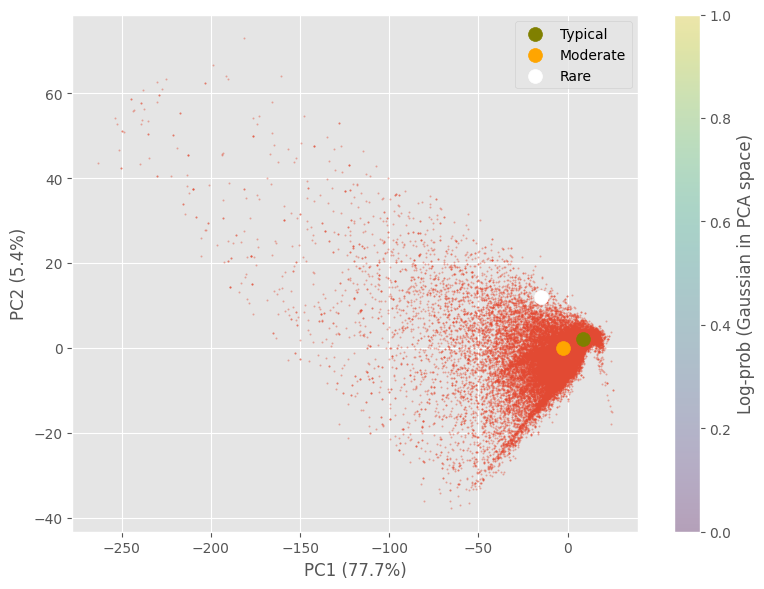

In [23]:
plt.figure(figsize=(8,6))
plt.scatter(ys_pca[:, 0], ys_pca[:, 1], cmap='viridis', s=1, alpha=0.3)
plt.colorbar(label='Log-prob (Gaussian in PCA space)')

plt.scatter(ys_pca[idx_typical,  0], ys_pca[idx_typical,  1], color='olive',    s=100, zorder=5, label='Typical')
plt.scatter(ys_pca[idx_moderate, 0], ys_pca[idx_moderate, 1], color='orange', s=100, zorder=5, label='Moderate')
plt.scatter(ys_pca[idx_rare,     0], ys_pca[idx_rare,     1], color='white',  s=100, zorder=5, label='Rare')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend()
plt.tight_layout()
plt.show()

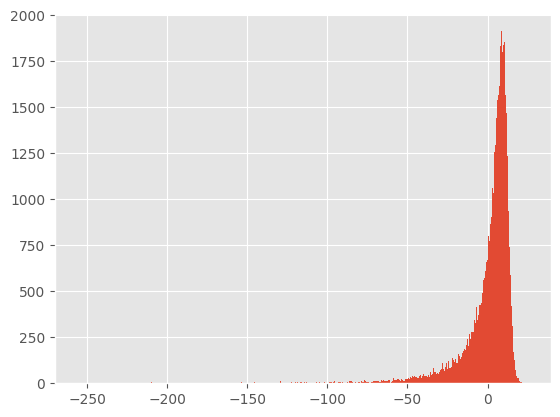

In [14]:
plt.hist(ys_pca[:, 0], bins=1000);

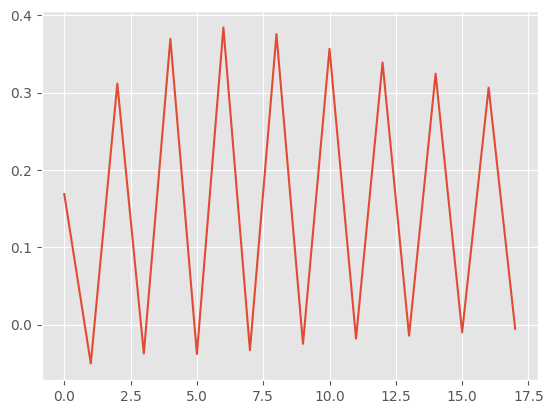

In [165]:
plt.plot(pca.components_[0])

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")

In [4]:
us_true = np.exp(np.load("true_samps/true_us_obs.npy")[::20, :])
us_mod = np.exp(np.load("true_samps/true_us_moderate_obs_2.npy")[::10, :])
us_rare = np.exp(np.load("true_samps/true_us_rare_obs_3.npy")[::10, :])

In [5]:
us_true

array([[0.80078335, 0.03416981, 1.15080145, 0.04794453],
       [0.58093737, 0.0262266 , 1.3959781 , 0.05450287],
       [0.71518405, 0.04081389, 1.10614626, 0.05062659],
       ...,
       [1.08833703, 0.0702377 , 0.89966248, 0.02099124],
       [1.14042648, 0.10605393, 0.72768432, 0.028032  ],
       [0.87089848, 0.06310774, 1.00429763, 0.03058203]], shape=(25000, 4))

In [7]:
u_moderate = np.array([1.0251955 , 0.02654782, 1.1242096 , 0.2028351 ])
u_rare = np.array([0.442866  , 0.03737646, 0.13543342, 0.03316975])
u_true = np.array([0.83194674, 0.04134147, 1.0823151, 0.03991483])

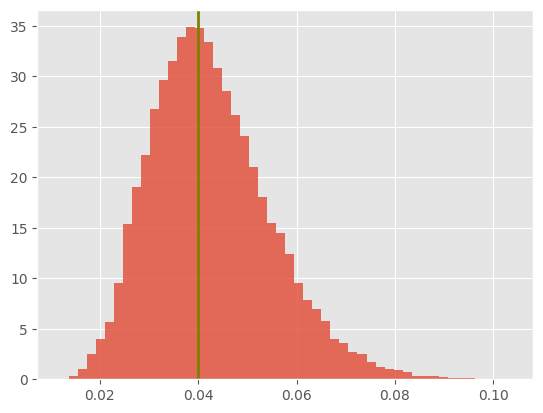

In [11]:
plt.hist(us_true[:, 3], bins=50, density=True, alpha=0.8);
plt.axvline(u_true[3], c="olive", linewidth=2)

In [12]:
np.load("training_data.npy")

array([[1.88939789e+02, 7.01760411e-01, 4.32008171e+01, ...,
        1.15377065e-02, 2.54539919e+00, 4.33528684e-02],
       [1.27292549e+02, 6.55826628e-01, 2.46629654e+02, ...,
        9.25227925e-02, 3.34966660e-01, 1.15984548e-02],
       [2.42660873e+02, 1.03724184e+01, 3.61216712e+00, ...,
        6.54219463e-02, 9.58210886e-01, 3.57936956e-02],
       ...,
       [1.19702228e-04, 1.43993210e+02, 1.78414996e-06, ...,
        3.95335034e-02, 7.40897715e-01, 3.07319164e-01],
       [1.09957056e+01, 1.16981196e+00, 1.97364843e+00, ...,
        1.08343698e-01, 5.97886086e-01, 3.88288423e-02],
       [7.79571075e+01, 2.30645752e+00, 3.52822189e+01, ...,
        6.13745190e-02, 3.43748450e-01, 2.27933228e-02]],
      shape=(100000, 22), dtype=float32)